In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
df_index = pd.read_csv("economic_index.csv")

In [3]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
#drop unnecessary columns

df_index.drop(columns=["Unnamed: 0","year","month"],axis = 1,inplace=True)


In [5]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [6]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

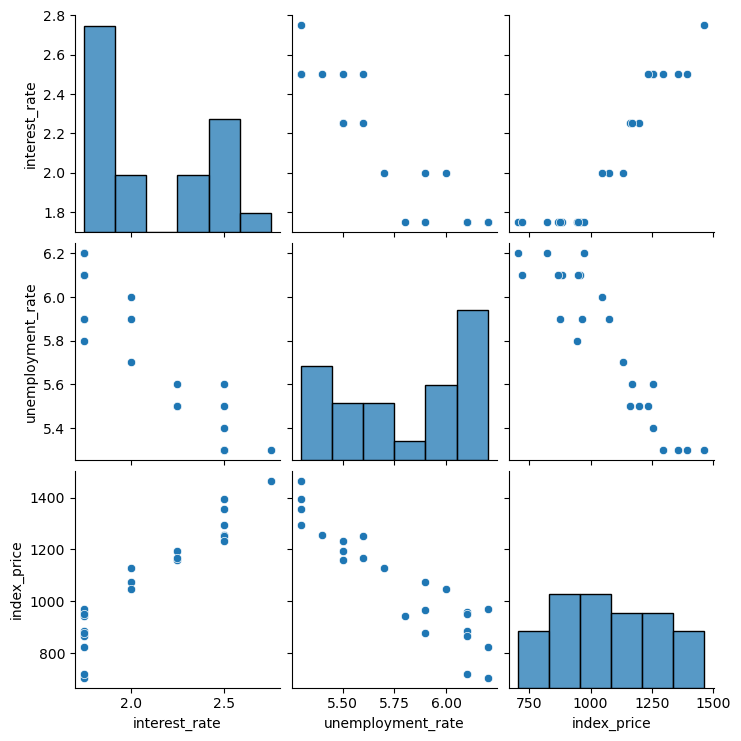

In [7]:
#vusualization

import seaborn as sns 
sns.pairplot(df_index)
plt.show()

In [8]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


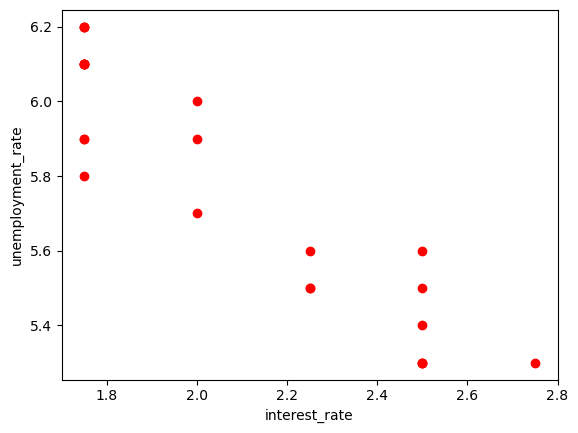

In [9]:
## visualize data point
plt.scatter(df_index['interest_rate'],df_index["unemployment_rate"],color = 'r')
plt.xlabel("interest_rate")
plt.ylabel("unemployment_rate")
plt.show()

In [10]:
## independent and dependent feature

X = df_index[['interest_rate','unemployment_rate']]
y = df_index['index_price']

In [11]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [12]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [13]:
#train test split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

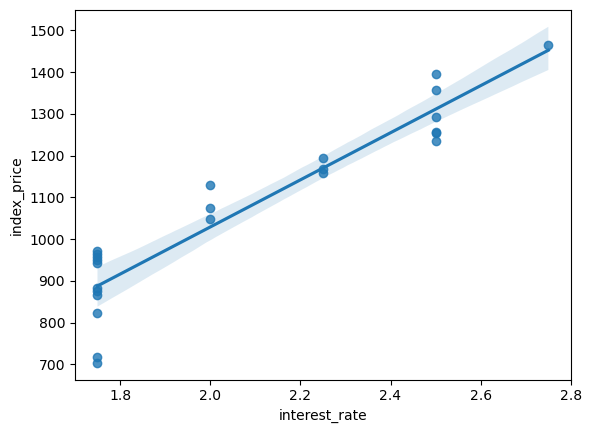

In [14]:
import seaborn as sns 
sns.regplot(x=df_index['interest_rate'],y=df_index['index_price'])
plt.show()

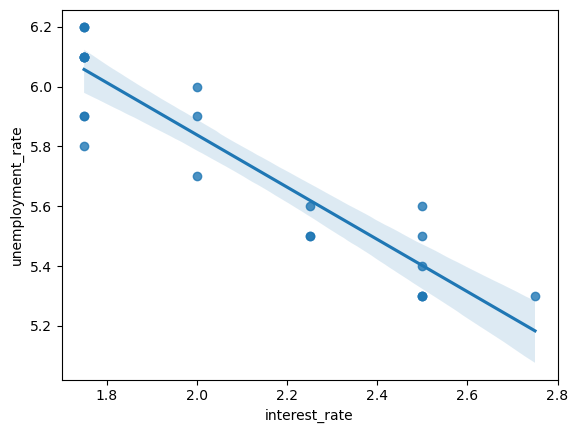

In [15]:
import seaborn as sns 
sns.regplot(x=df_index['interest_rate'],y=df_index['unemployment_rate'])
plt.show()

In [16]:
#scaling

from sklearn.preprocessing import StandardScaler


In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [19]:
regression.fit(X_train,y_train)

LinearRegression()

In [20]:
## cross validation
from sklearn.model_selection import cross_val_score

validation_score = cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [21]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [22]:
validation_score.mean()

np.float64(-5914.828180162396)

In [23]:
##prediction
y_pred = regression.predict(X_test)


In [24]:
## performance metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse  = mean_squared_error(y_test,y_pred)
mae  = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print("MSE :",mse)
print("MAE :",mae)
print("RMSE :",rmse)


MSE : 5793.76288771258
MAE : 59.93578152323556
RMSE : 76.11677139574813


In [25]:
# r2 and adjusted r2 score
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print("R2 score :",r2)
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
print("Adjusted R2 score :",adjusted_r2)

R2 score : 0.8278978091457142
Adjusted R2 score : 0.713163015242857


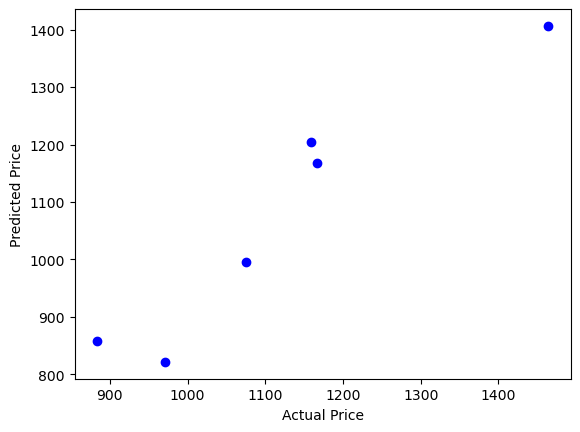

In [26]:
plt.scatter(y_test,y_pred,color='b')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [27]:
residuals = y_test - y_pred
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


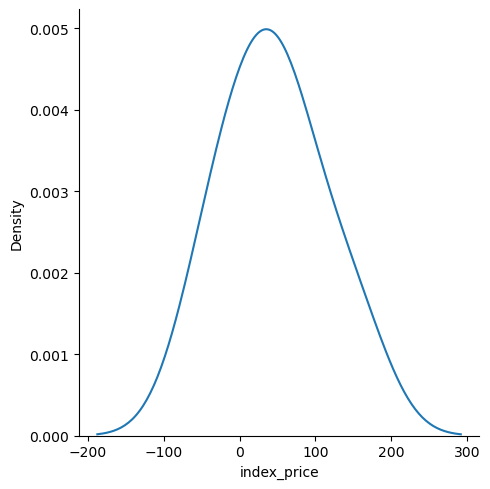

In [28]:
##plot residuals
sns.displot(residuals,kind='kde')
plt.show()

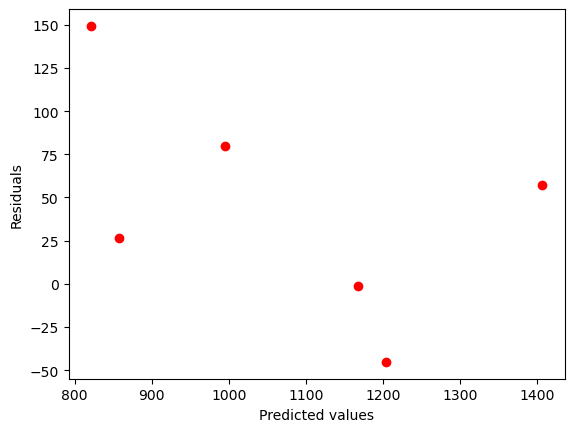

In [29]:
##scater plot with resepect to predicted values and values of residuals
plt.scatter(y_pred,residuals,color='r')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.show()